# Занятие 36. Практика: решающее дерево (~90 мин)

**Только для преподавателя. Не выдавать студентам.**

Эталон практики. Ячейку **«Дано»** не меняйте.

Главная модель — **DecisionTreeClassifier** (теория — занятие 35, `decision_tree_theory.ipynb`).

На `make_moons` сравним глубокие и ограниченные деревья, подберём `max_depth` и посмотрим обрезку (п. 11 теории).

Термины и определения — в теоретическом ноутбуке. Здесь только практика.

---
## Дано: классификация make_moons

Два полумесяца — нелинейная граница. Масштабирование для дерева не обязательно (п. 12).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=350, noise=0.3, random_state=42)
print('Объектов:', len(X), '| классы:', np.bincount(y))

Объектов: 350 | классы: [175 175]


---
## Задание 0. Split и импорты (~8 мин)

`train_test_split`, `DecisionTreeClassifier`, `accuracy_score`, `plot_tree`, `confusion_matrix`, `RANDOM_STATE=42`, split 65/35 со `stratify`.

**Критерий:** `X_train`, `X_val`, `y_train`, `y_val`.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_STATE = 42
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=RANDOM_STATE
)

---
## Задание 1. Глубина и переобучение (~15 мин)

По п. 11. Обучите деревья с `max_depth` in `[1, 3, 6, None]`. Таблица train/validation accuracy.

**Критерий:** при `None` train ≈ 1.0, validation хуже.

In [3]:
for d in [1, 3, 6, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    va = accuracy_score(y_val, m.predict(X_val))
    print(f'max_depth={d!s:4} train={tr:.3f} val={va:.3f}')

max_depth=1    train=0.824 val=0.732
max_depth=3    train=0.899 val=0.862
max_depth=6    train=0.982 val=0.870
max_depth=None train=1.000 val=0.870


---
## Задание 2. Подбор max_depth (~15 мин)

Переберите `max_depth` от 1 до 12. Выберите лучший по **validation accuracy**.

**Критерий:** переменная `best_depth`.

In [4]:
rows = []
for d in range(1, 13):
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    va = accuracy_score(y_val, m.predict(X_val))
    rows.append((d, va))
best_depth = max(rows, key=lambda x: x[1])[0]
print('best_depth:', best_depth, 'val acc:', round(max(rows, key=lambda x: x[1])[1], 3))

best_depth: 4 val acc: 0.87


---
## Задание 3. Визуализация дерева (~12 мин)

По п. 1. `plot_tree` для модели с `best_depth` (figsize ≥ 10).

**Критерий:** график отображается.

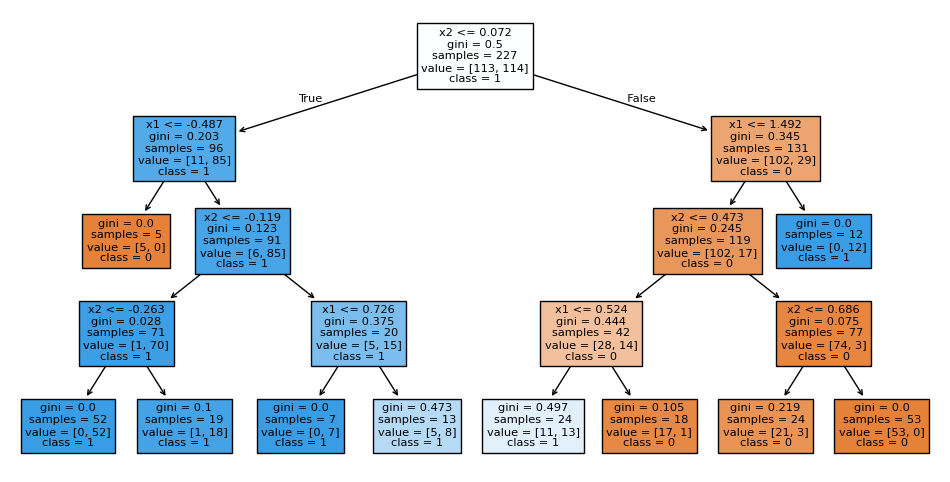

In [5]:
best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE).fit(X_train, y_train)
plt.figure(figsize=(12, 6))
plot_tree(best, feature_names=['x1', 'x2'], class_names=['0', '1'], filled=True)
plt.show()

---
## Задание 4. min_samples_leaf (~12 мин)

При фиксированном `best_depth` попробуйте `min_samples_leaf` in `[1, 5, 15]`. Сравните validation accuracy (п. 11).

**Критерий:** таблица из 3 строк.

In [6]:
for leaf in [1, 5, 15]:
    m = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=leaf, random_state=RANDOM_STATE).fit(X_train, y_train)
    print(f'min_samples_leaf={leaf} val acc={accuracy_score(y_val, m.predict(X_val)):.3f}')

min_samples_leaf=1 val acc=0.870
min_samples_leaf=5 val acc=0.870
min_samples_leaf=15 val acc=0.829


---
## Задание 5. ccp_alpha (~12 мин)

По п. 11 (post-pruning). Для полного дерева (`max_depth=None`) выведите число листьев при `ccp_alpha` in `[0, 0.005, 0.02, 0.08]`.

**Критерий:** листьев становится меньше при росте alpha.

In [7]:
for alpha in [0.0, 0.005, 0.02, 0.08]:
    m = DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE).fit(X_train, y_train)
    print(f'ccp_alpha={alpha} leaves={m.get_n_leaves()} depth={m.get_depth()}')

ccp_alpha=0.0 leaves=24 depth=9
ccp_alpha=0.005 leaves=12 depth=5
ccp_alpha=0.02 leaves=7 depth=5
ccp_alpha=0.08 leaves=2 depth=1


---
## Задание 6. Confusion matrix (~10 мин)

Матрица ошибок лучшего дерева на validation.

**Критерий:** `confusion_matrix(y_val, y_pred)`.

In [8]:
final = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE).fit(X_train, y_train)
y_pred = final.predict(X_val)
print(confusion_matrix(y_val, y_pred))

[[54  8]
 [ 8 53]]


---
## Задание 7. Feature importance (~10 мин)

По п. 13. Выведите `feature_importances_`. Кратко в markdown: почему importance не доказывает причинность?

**Критерий:** два числа importance.

In [9]:
print('importance:', final.feature_importances_)

importance: [0.35297832 0.64702168]


---
## Задание 8. Итог (~5 мин)

Три вывода: переобучение глубокого дерева, польза ограничений, интерпретируемость.

**Критерий:** markdown с тремя пунктами.